<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Air_Pollution_PM2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

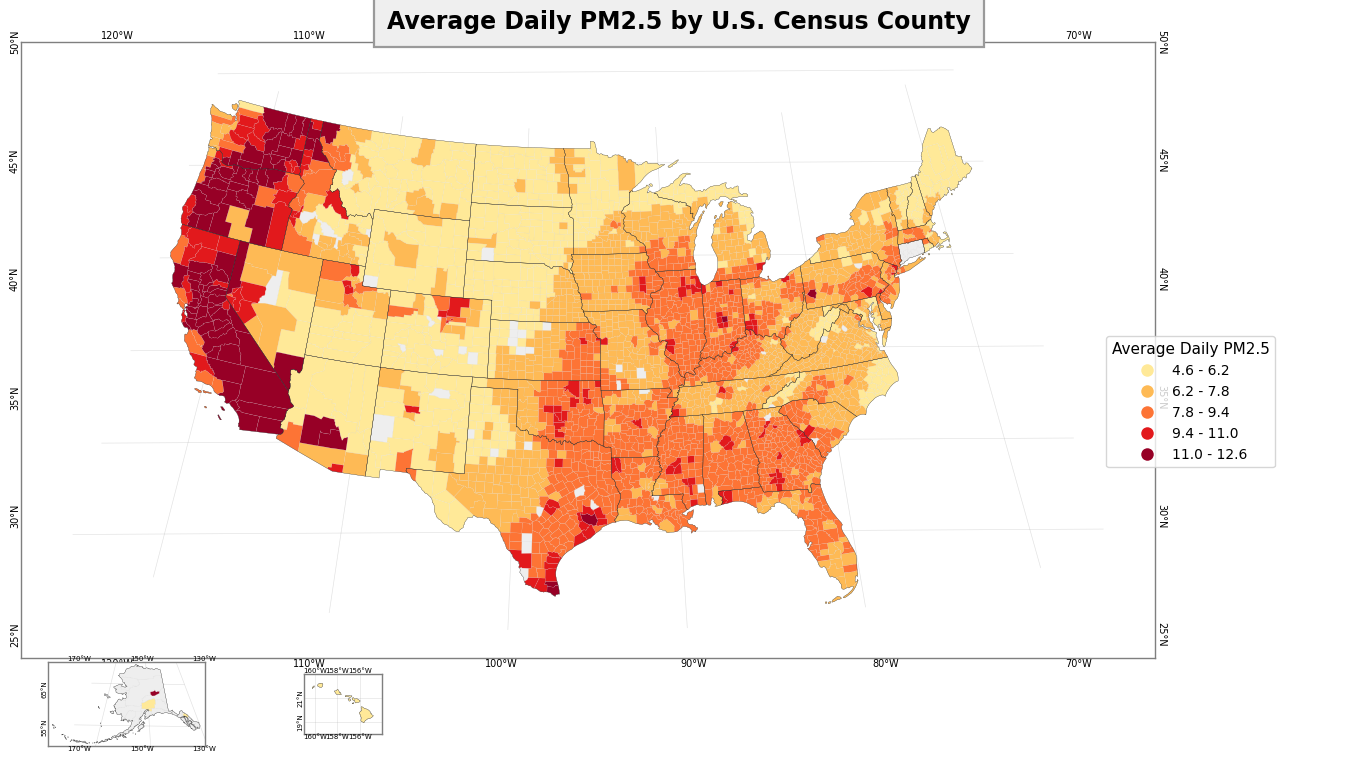

In [9]:
# Run once
# ! pip install numpy geopandas pandas matplotlib openpyxl shapely

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import LineString

file = "/content/2025 County Health Rankings Data - v4.xlsx"

# Load County Health Rankings data
excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

air_pollution = excel_data[[
    "FIPS",
    "State",
    "County",
    "Average Daily PM2.5"
]].copy()

# Keep county rows only
air_pollution = air_pollution[air_pollution["County"].notna()].copy()

# Clean FIPS and PM2.5 column
air_pollution["FIPS"] = air_pollution["FIPS"].astype(int).astype(str).str.zfill(5)

air_pollution["Average Daily PM2.5"] = pd.to_numeric(
    air_pollution["Average Daily PM2.5"],
    errors="coerce"
)

# Load county shapefile from U.S. Census Bureau
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

counties = counties.to_crs(epsg=4326)

# Merge county map with PM2.5 data
merged = counties.merge(
    air_pollution,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Color scale
pm_values = merged["Average Daily PM2.5"].dropna()
vmin = pm_values.quantile(0.02)
vmax = pm_values.quantile(0.98)

# Create PM2.5 range bins
bins = np.linspace(vmin, vmax, 6)

range_labels = [
    f"{bins[i]:.1f} - {bins[i + 1]:.1f}"
    for i in range(len(bins) - 1)
]

# Put each county into a range
merged["pm_bin"] = pd.cut(
    merged["Average Daily PM2.5"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Put out-of-range values into first/last bins
merged.loc[merged["Average Daily PM2.5"] < vmin, "pm_bin"] = 0
merged.loc[merged["Average Daily PM2.5"] > vmax, "pm_bin"] = 4

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Create state boundary layers
lower48_states = lower48_proj.dissolve(by="STATEFP")
alaska_states = alaska_proj.dissolve(by="STATEFP")
hawaii_states = hawaii_proj.dissolve(by="STATEFP")

# Colors for each PM2.5 range
colors = plt.cm.YlOrRd(np.linspace(0.15, 0.95, 5))
missing_color = "#eeeeee"

# Function to plot bins safely
def plot_pm_map(ax, gdf, linewidth):
    missing = gdf[gdf["pm_bin"].isna()]

    if not missing.empty:
        missing.plot(
            color=missing_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax,
            zorder=2
        )

    for i in range(5):
        bin_df = gdf[gdf["pm_bin"] == i]

        if not bin_df.empty:
            bin_df.plot(
                color=colors[i],
                edgecolor="lightgray",
                linewidth=linewidth,
                ax=ax,
                zorder=3
            )

# Format longitude and latitude labels
def format_lon(lon):
    return f"{abs(int(lon))}°W"

def format_lat(lat):
    return f"{abs(int(lat))}°N"

# Add grid lines, but place labels directly on the frame edges
def add_lat_lon_grid_with_frame_labels(
    ax,
    target_crs,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    show_top=True,
    show_bottom=True,
    show_left=True,
    show_right=True,
    lon_fontsize=7,
    lat_fontsize=7,
    grid_color="#a9a9a9",
    grid_alpha=0.35
):
    # Longitude grid lines and labels
    for lon in lon_values:
        line = LineString([(lon, lat_min), (lon, lat_max)])
        line_gdf = gpd.GeoDataFrame(
            geometry=[line],
            crs="EPSG:4326"
        ).to_crs(target_crs)

        line_gdf.plot(
            ax=ax,
            color=grid_color,
            linewidth=0.45,
            alpha=grid_alpha,
            zorder=1
        )

        x_frac = (lon - lon_min) / (lon_max - lon_min)

        if show_top:
            ax.text(
                x_frac,
                1.001,
                format_lon(lon),
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=lon_fontsize,
                color="black",
                clip_on=False
            )

        if show_bottom:
            ax.text(
                x_frac,
                -0.001,
                format_lon(lon),
                transform=ax.transAxes,
                ha="center",
                va="top",
                fontsize=lon_fontsize,
                color="black",
                clip_on=False
            )

    # Latitude grid lines and labels
    for lat in lat_values:
        line = LineString([(lon_min, lat), (lon_max, lat)])
        line_gdf = gpd.GeoDataFrame(
            geometry=[line],
            crs="EPSG:4326"
        ).to_crs(target_crs)

        line_gdf.plot(
            ax=ax,
            color=grid_color,
            linewidth=0.45,
            alpha=grid_alpha,
            zorder=1
        )

        y_frac = (lat - lat_min) / (lat_max - lat_min)

        if show_left:
            ax.text(
                -0.001,
                y_frac,
                format_lat(lat),
                transform=ax.transAxes,
                ha="right",
                va="center",
                rotation=90,
                fontsize=lat_fontsize,
                color="black",
                clip_on=False
            )

        if show_right:
            ax.text(
                1.001,
                y_frac,
                format_lat(lat),
                transform=ax.transAxes,
                ha="left",
                va="center",
                rotation=270,
                fontsize=lat_fontsize,
                color="black",
                clip_on=False
            )

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main map
ax_main = fig.add_axes([0.02, 0.16, 0.83, 0.77])
ax_main.set_facecolor("white")

# Add longitude and latitude grid labels along the frame
add_lat_lon_grid_with_frame_labels(
    ax=ax_main,
    target_crs="EPSG:5070",
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125,
    lon_max=-66,
    lat_min=24,
    lat_max=50,
    show_top=True,
    show_bottom=True,
    show_left=True,
    show_right=True,
    lon_fontsize=7,
    lat_fontsize=7
)

# Plot PM2.5 map
plot_pm_map(ax_main, lower48_proj, 0.08)

# Thin black state borders
lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.18,
    zorder=4
)

# Add main map frame
for spine in ax_main.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#7f7f7f")

ax_main.set_xticks([])
ax_main.set_yticks([])

# Alaska inset
ax_ak = fig.add_axes([0.03, 0.05, 0.15, 0.105])
ax_ak.set_facecolor("white")

add_lat_lon_grid_with_frame_labels(
    ax=ax_ak,
    target_crs="EPSG:3338",
    lon_values=[-170, -150, -130],
    lat_values=[55, 65],
    lon_min=-180,
    lon_max=-130,
    lat_min=50,
    lat_max=72,
    show_top=True,
    show_bottom=True,
    show_left=True,
    show_right=False,
    lon_fontsize=5,
    lat_fontsize=5
)

plot_pm_map(ax_ak, alaska_proj, 0.10)

alaska_states.boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=0.20,
    zorder=4
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset
ax_hi = fig.add_axes([0.21, 0.065, 0.10, 0.075])
ax_hi.set_facecolor("white")

add_lat_lon_grid_with_frame_labels(
    ax=ax_hi,
    target_crs="EPSG:4326",
    lon_values=[-160, -158, -156],
    lat_values=[19, 21],
    lon_min=-161,
    lon_max=-154,
    lat_min=18,
    lat_max=23,
    show_top=True,
    show_bottom=True,
    show_left=True,
    show_right=False,
    lon_fontsize=5,
    lat_fontsize=5
)

plot_pm_map(ax_hi, hawaii_proj, 0.10)

hawaii_states.boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=0.20,
    zorder=4
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Legend
legend_handles = []

for i, label in enumerate(range_labels):
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            label=label,
            markerfacecolor=colors[i],
            markeredgecolor="none",
            markersize=9
        )
    )

ax_leg = fig.add_axes([0.80, 0.36, 0.18, 0.24])
ax_leg.axis("off")

ax_leg.legend(
    handles=legend_handles,
    title="Average Daily PM2.5",
    loc="center left",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

# Title box
fig.text(
    0.5,
    0.955,
    "Average Daily PM2.5 by U.S. Census County",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.55",
        linewidth=1.6
    )
)

plt.show()